## Alzheimer's project

In [2]:
import pandas as pd

df = pd.read_csv('alzheimers_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(2149, 35)
Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQual

In [4]:
## Drop PatientID and DoctorInCharge as they are not useful for the model
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

print(df.shape)

(2149, 33)


## Feature Engineering

In [5]:
# ── Feature Engineering ──

# Combine Age and BMI to create a new risk feature
df['Age_BMI'] = df['Age'] * df['BMI']

# Combine MMSE and FunctionalAssessment as cognitive score
df['Cognitive_Score'] = df['MMSE'] + df['FunctionalAssessment']

print("New features added!")
print(df[['Age', 'BMI', 'Age_BMI', 'MMSE', 'FunctionalAssessment', 'Cognitive_Score']].head())

New features added!
   Age        BMI      Age_BMI       MMSE  FunctionalAssessment  \
0   73  22.927749  1673.725694  21.463532              6.518877   
1   89  26.827681  2387.663626  20.613267              7.118696   
2   73  17.795882  1299.099418   7.356249              5.895077   
3   74  33.800817  2501.260461  13.991127              8.965106   
4   89  20.716974  1843.810671  13.517609              6.045039   

   Cognitive_Score  
0        27.982409  
1        27.731963  
2        13.251326  
3        22.956234  
4        19.562648  


## Feature and Target

In [6]:

# X = input features (all columns except Diagnosis)
X = df.drop('Diagnosis', axis=1)

# y = target column (what we want to predict)
y = df['Diagnosis']

# Check the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2149, 34)
y shape: (2149,)


## Data Train & Test

In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into 70% training and 30% testing as per paper
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Check the sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1504, 34)
X_test shape: (645, 34)


## Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


## Feature Distribution Charts

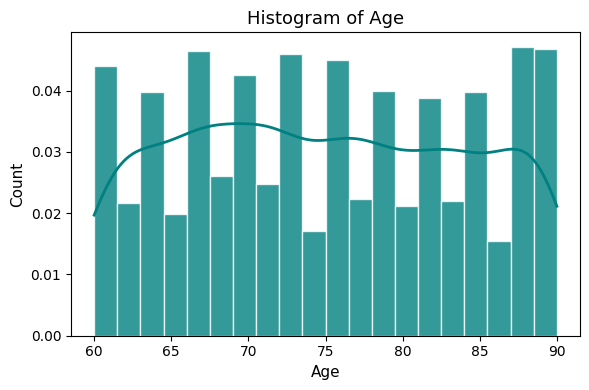

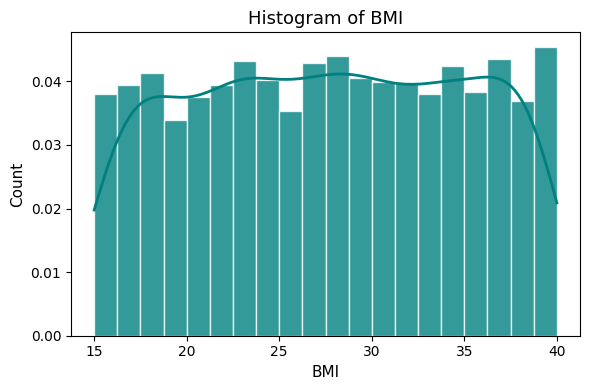

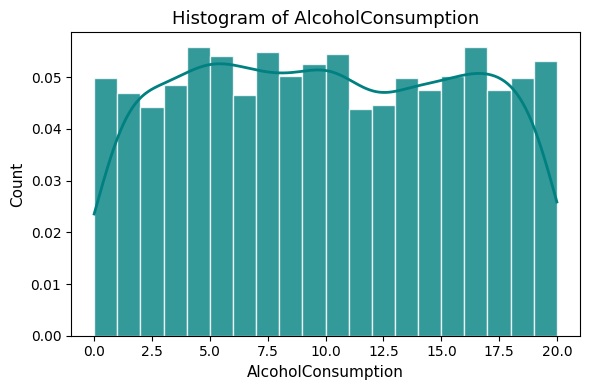

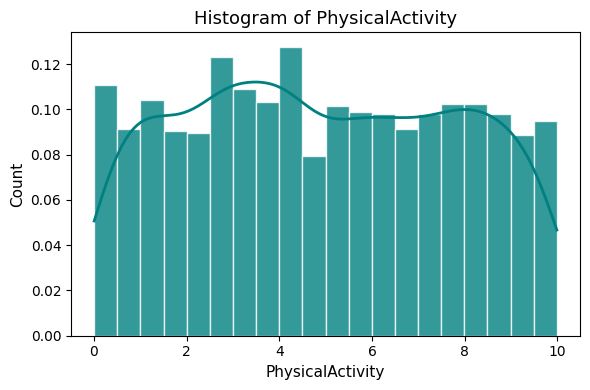

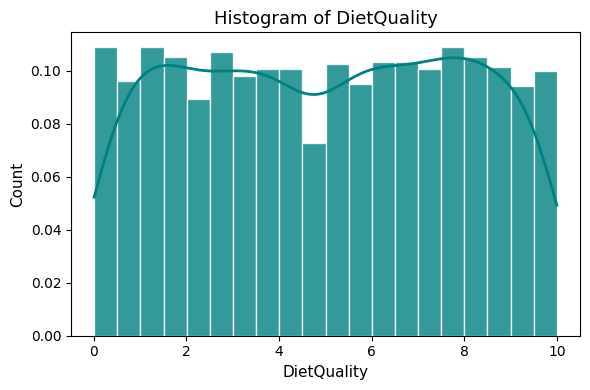

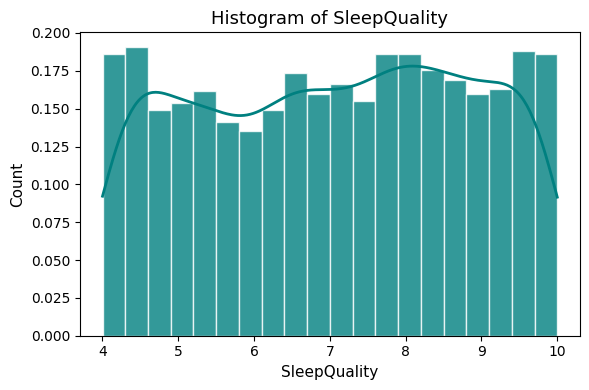

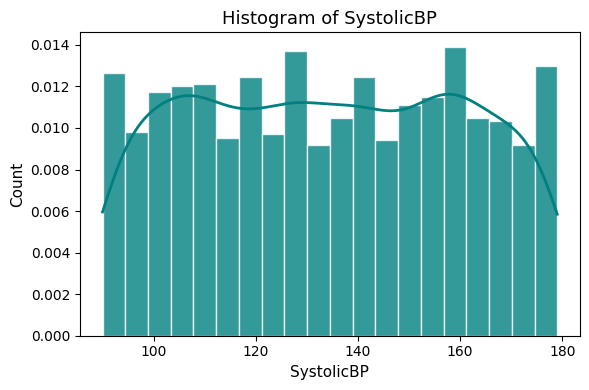

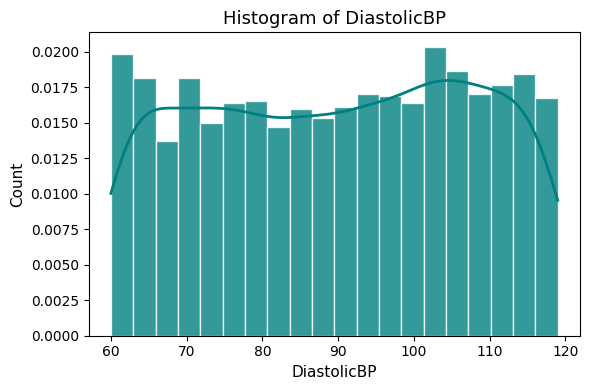

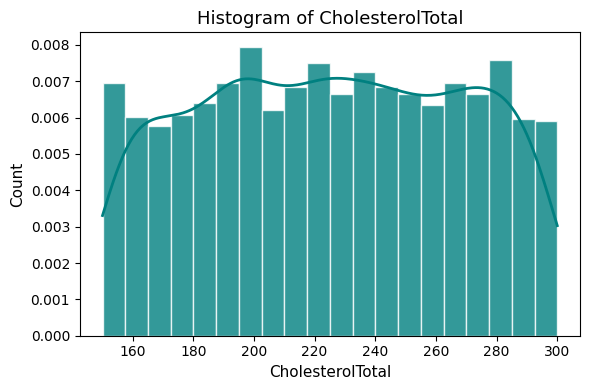

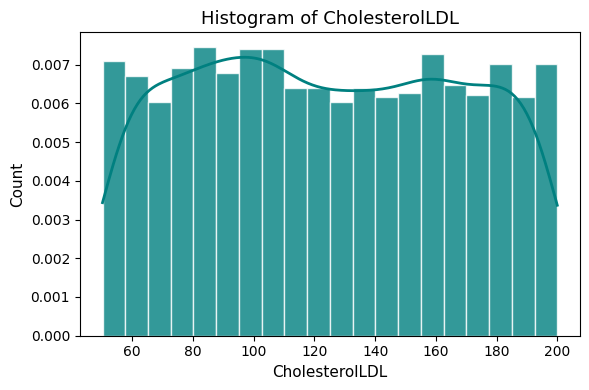

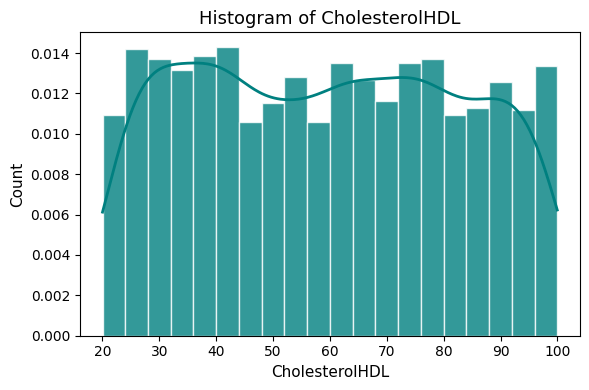

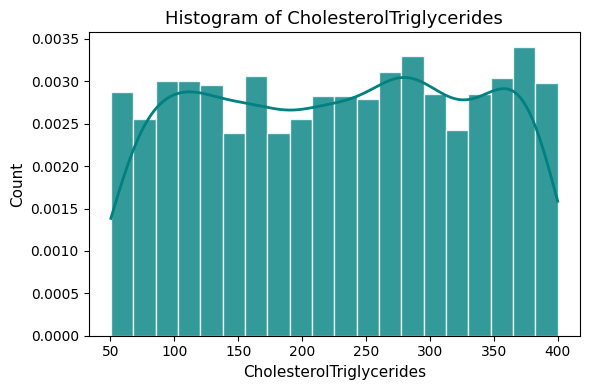

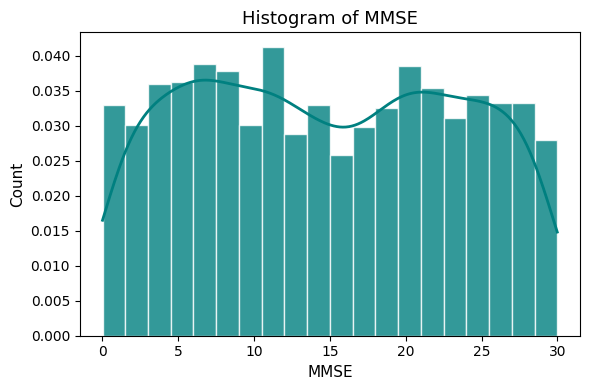

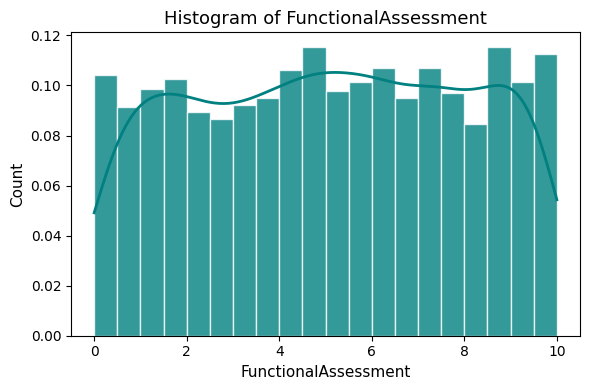

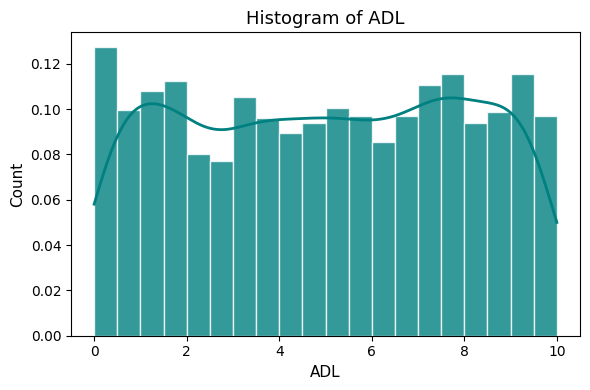

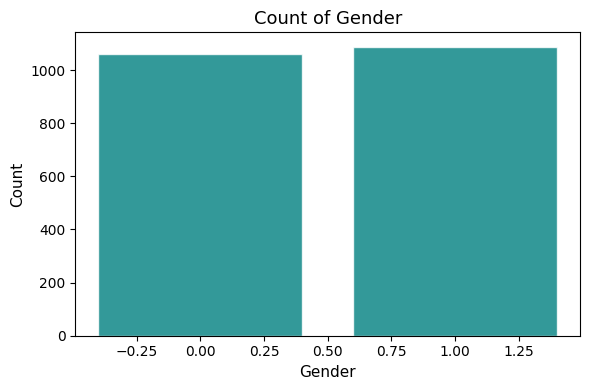

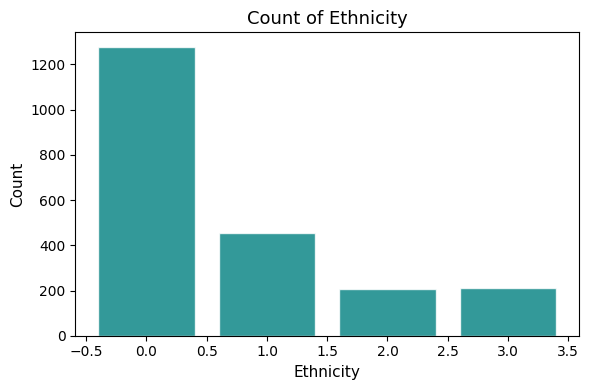

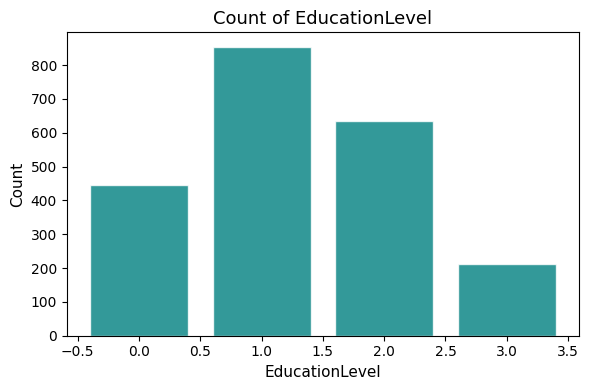

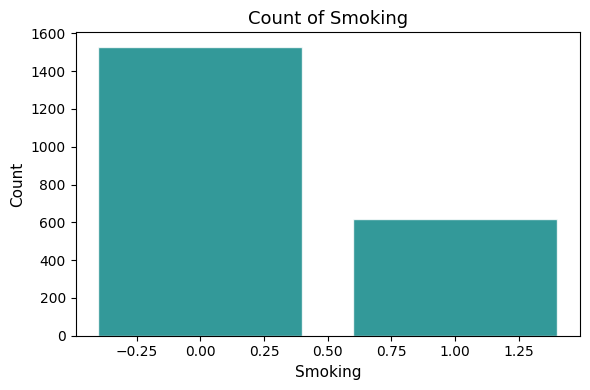

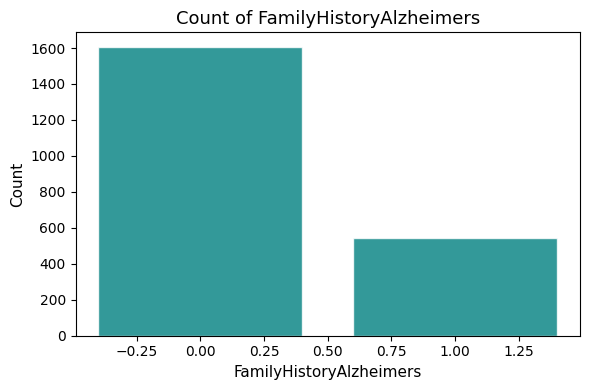

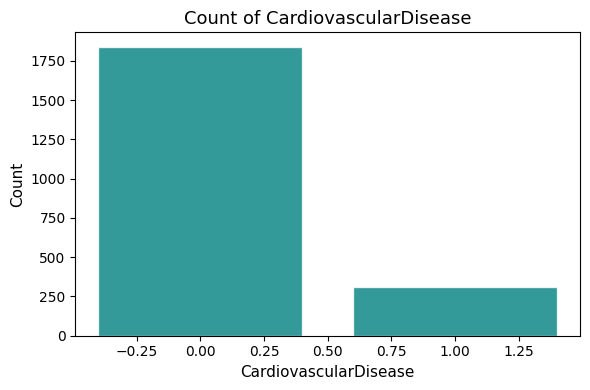

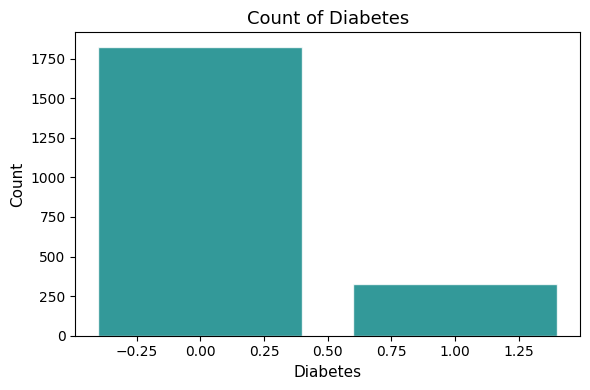

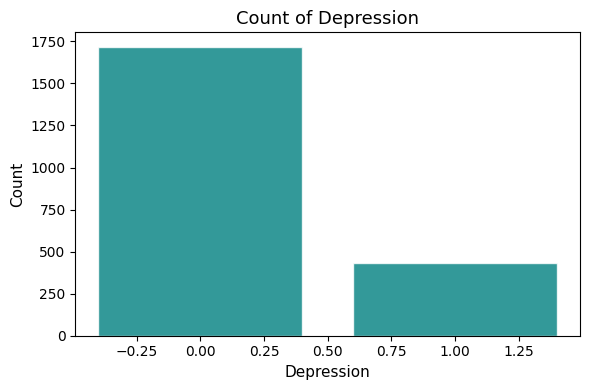

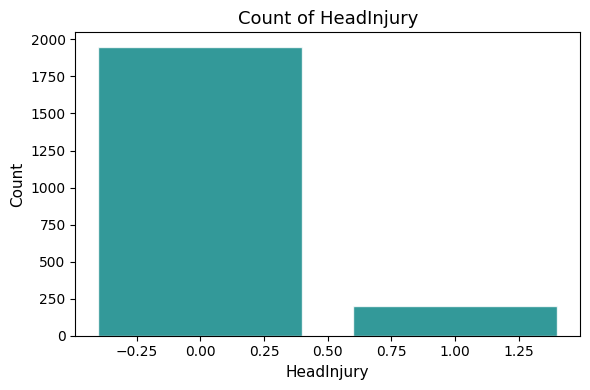

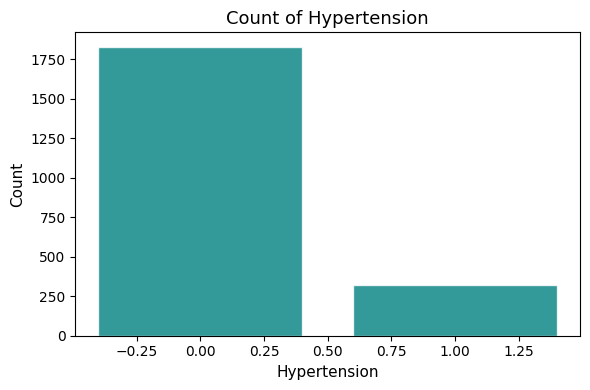

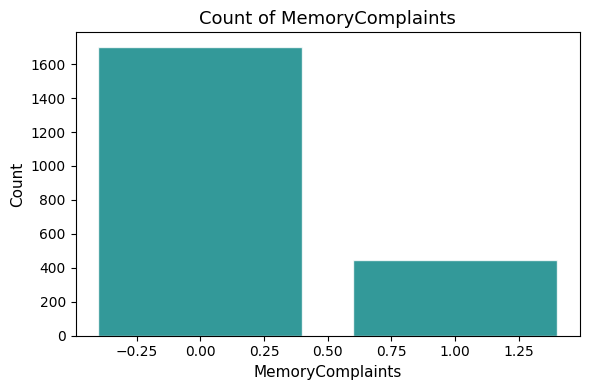

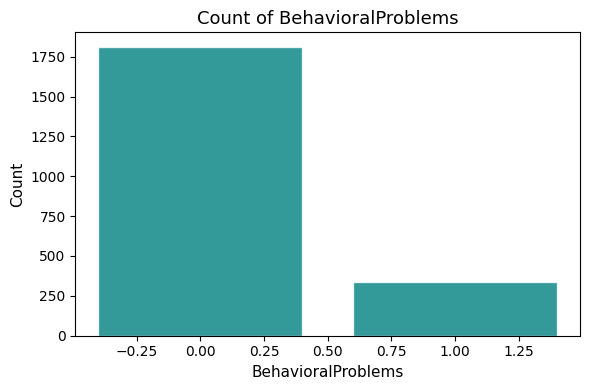

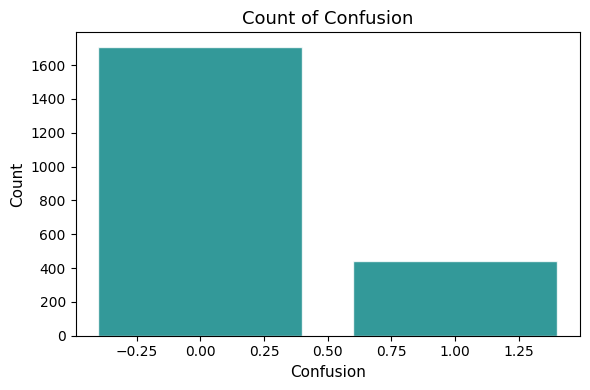

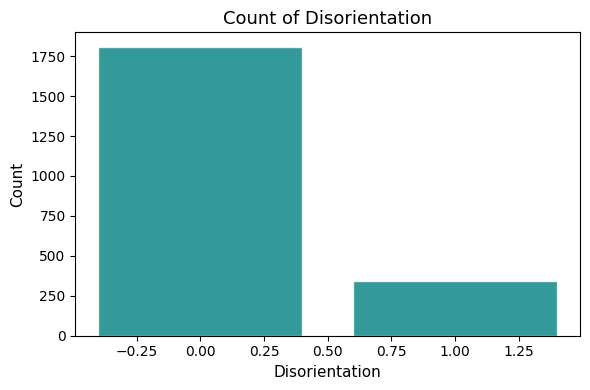

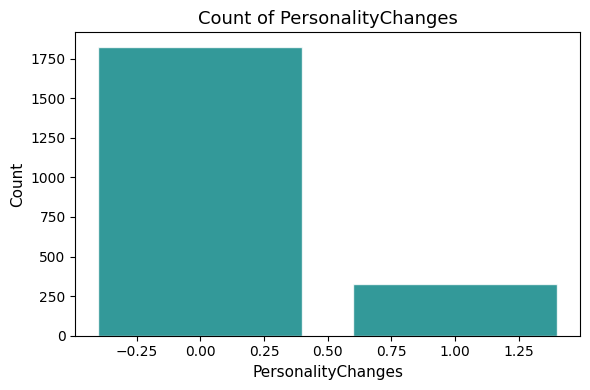

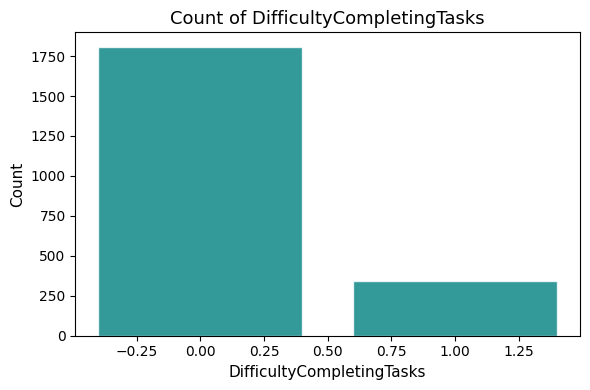

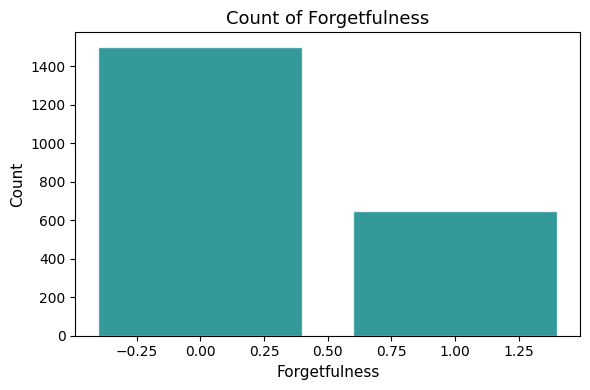

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Numerical features — Histogram with curve
numerical_cols = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                  'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                  'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                  'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

# Categorical features — Count bar chart
categorical_cols = ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
                    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
                    'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints',
                    'BehavioralProblems', 'Confusion', 'Disorientation',
                    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']

# Plot Histograms for numerical features
for col in numerical_cols:
    fig, ax = plt.subplots(figsize=(6, 4))

    # Histogram with teal color
    ax.hist(df[col], bins=20, color='teal', edgecolor='white', alpha=0.8, density=True)

    # Smooth curve on top
    data = df[col].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, kde(x_range), color='teal', linewidth=2)

    ax.set_title(f'Histogram of {col}', fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'histogram_{col}.png', dpi=150)
    plt.show()

# Plot Count charts for categorical features
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(6, 4))

    # Count of each category
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='teal', edgecolor='white', alpha=0.8)

    ax.set_title(f'Count of {col}', fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'count_{col}.png', dpi=150)
    plt.show()

## KNN Algorithm

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from numpy.linalg import pinv
import numpy as np

# ── KNN (k=3, Euclidean Distance) ──
knn_3 = KNeighborsClassifier(n_neighbors=3)
scores_3 = cross_val_score(knn_3, X_train, y_train, cv=10)
print("=== KNN (k=3, Euclidean) ===")
print(f"Mean Accuracy: {scores_3.mean()*100:.2f}%")

# ── KNN (k=10, Euclidean Distance) ──
knn_10 = KNeighborsClassifier(n_neighbors=10)
scores_10 = cross_val_score(knn_10, X_train, y_train, cv=10)
print("\n=== KNN (k=10, Euclidean) ===")
print(f"Mean Accuracy: {scores_10.mean()*100:.2f}%")

# ── KNN (Minkowski, p=32) ──
knn_mink = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=32)
scores_mink = cross_val_score(knn_mink, X_train, y_train, cv=10)
print("\n=== KNN (Minkowski p=32) ===")
print(f"Mean Accuracy: {scores_mink.mean()*100:.2f}%")

# ── KNN (Mahalanobis Distance) ──
cov_matrix = np.cov(X_train.T)
VI = pinv(cov_matrix)
knn_maha = KNeighborsClassifier(n_neighbors=3, metric='mahalanobis', metric_params={'VI': VI})
scores_maha = cross_val_score(knn_maha, X_train, y_train, cv=10)
print("\n=== KNN (Mahalanobis) ===")
print(f"Mean Accuracy: {scores_maha.mean()*100:.2f}%")

# ── KNN (Canberra Distance) ──
knn_can = KNeighborsClassifier(n_neighbors=3, metric='canberra')
scores_can = cross_val_score(knn_can, X_train, y_train, cv=10)
print("\n=== KNN (Canberra) ===")
print(f"Mean Accuracy: {scores_can.mean()*100:.2f}%")

# ── KNN (weights=distance) ──
knn_wt = KNeighborsClassifier(n_neighbors=3, weights='distance')
scores_wt = cross_val_score(knn_wt, X_train, y_train, cv=10)
print("\n=== KNN (weights=distance) ===")
print(f"Mean Accuracy: {scores_wt.mean()*100:.2f}%")

=== KNN (k=3, Euclidean) ===
Mean Accuracy: 74.80%

=== KNN (k=10, Euclidean) ===
Mean Accuracy: 75.66%

=== KNN (Minkowski p=32) ===
Mean Accuracy: 68.02%

=== KNN (Mahalanobis) ===
Mean Accuracy: 73.40%

=== KNN (Canberra) ===
Mean Accuracy: 76.86%

=== KNN (weights=distance) ===
Mean Accuracy: 74.80%


##  Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# ── Logistic Regression (max_iter=10000) ──
lr = LogisticRegression(max_iter=10000)

# 10-Fold Cross Validation
lr_scores = cross_val_score(lr, X_train, y_train, cv=10)

print("=== Logistic Regression ===")
print(f"Accuracy per fold: {lr_scores}")
print(f"Mean Accuracy: {lr_scores.mean()*100:.2f}%")

=== Logistic Regression ===
Accuracy per fold: [0.8410596  0.83443709 0.86754967 0.89403974 0.84       0.86
 0.85333333 0.88       0.81333333 0.79333333]
Mean Accuracy: 84.77%


## Support Vector Machine (SVM)

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# ── SVM (RBF Kernel, max_iter=10000) ──
svm = SVC(max_iter=10000)

# 10-Fold Cross Validation
svm_scores = cross_val_score(svm, X_train, y_train, cv=10)

print("=== Support Vector Machine (SVM) ===")
print(f"Accuracy per fold: {svm_scores}")
print(f"Mean Accuracy: {svm_scores.mean()*100:.2f}%")

=== Support Vector Machine (SVM) ===
Accuracy per fold: [0.82781457 0.86754967 0.88741722 0.9205298  0.87333333 0.89333333
 0.82666667 0.86666667 0.80666667 0.80666667]
Mean Accuracy: 85.77%


##  Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# ── Random Forest (n_estimators=100) ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 10-Fold Cross Validation
rf_scores = cross_val_score(rf, X_train, y_train, cv=10)

print("=== Random Forest ===")
print(f"Accuracy per fold: {rf_scores}")
print(f"Mean Accuracy: {rf_scores.mean()*100:.2f}%")

=== Random Forest ===
Accuracy per fold: [0.90066225 0.94701987 0.90728477 0.95364238 0.93333333 0.95333333
 0.89333333 0.94       0.92666667 0.92666667]
Mean Accuracy: 92.82%


## Gaussian Naive Bayes

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

# ── Gaussian Naive Bayes ──
gnb = GaussianNB()

# 10-Fold Cross Validation
gnb_scores = cross_val_score(gnb, X_train, y_train, cv=10)

print("=== Gaussian Naive Bayes ===")
print(f"Accuracy per fold: {gnb_scores}")
print(f"Mean Accuracy: {gnb_scores.mean()*100:.2f}%")

=== Gaussian Naive Bayes ===
Accuracy per fold: [0.82781457 0.83443709 0.86092715 0.85430464 0.78666667 0.85333333
 0.83333333 0.86666667 0.80666667 0.78      ]
Mean Accuracy: 83.04%


## Proposed Model (Weighted KNN)

In [15]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# ── Proposed Model: Weighted KNN ──

def weighted_knn_distance(x, x_prime, coefficients):
    # Calculate weighted distance using the proposed formula from the paper
    numerator = np.sum(coefficients * (x - x_prime) ** 2)
    denominator = np.sum(coefficients ** 2)
    return np.sqrt(numerator / denominator)

def proposed_knn_predict(X_train, y_train, X_test, k=3):
    # Calculate feature importance as coefficients
    coefficients = np.var(X_train, axis=0) + 1e-10

    predictions = []
    for test_point in X_test:
        # Calculate weighted distance from test point to all training points
        distances = [
            weighted_knn_distance(test_point, train_point, coefficients)
            for train_point in X_train
        ]

        # Get k nearest neighbors
        k_nearest_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train.iloc[k_nearest_indices]

        # Majority vote
        prediction = k_nearest_labels.mode()[0]
        predictions.append(prediction)

    return np.array(predictions)

# 10-Fold Cross Validation for Proposed Model
kf = KFold(n_splits=10, shuffle=True, random_state=42)
proposed_scores = []

for train_index, val_index in kf.split(X_train):
    X_tr, X_val = X_train[train_index], X_train[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    y_pred = proposed_knn_predict(X_tr, y_tr, X_val, k=3)
    acc = accuracy_score(y_val, y_pred)
    proposed_scores.append(acc)

proposed_scores = np.array(proposed_scores)
print("=== Proposed Model (Weighted KNN) ===")
print(f"Accuracy per fold: {proposed_scores}")
print(f"Mean Accuracy: {proposed_scores.mean()*100:.2f}%")

=== Proposed Model (Weighted KNN) ===
Accuracy per fold: [0.78145695 0.70198675 0.74834437 0.78145695 0.75333333 0.74666667
 0.77333333 0.77333333 0.70666667 0.72666667]
Mean Accuracy: 74.93%


## Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

# ── KNN Hyperparameter Tuning ──
knn_params = {'n_neighbors': [3, 5, 7, 10]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=10)
knn_grid.fit(X_train, y_train)
print("=== KNN Best Params ===")
print(f"Best K: {knn_grid.best_params_}")
print(f"Best Accuracy: {knn_grid.best_score_*100:.2f}%")

# ── SVM Hyperparameter Tuning ──
svm_params = {'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=10)
svm_grid.fit(X_train, y_train)
print("\n=== SVM Best Params ===")
print(f"Best Params: {svm_grid.best_params_}")
print(f"Best Accuracy: {svm_grid.best_score_*100:.2f}%")

# ── Random Forest Hyperparameter Tuning ──
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=10)
rf_grid.fit(X_train, y_train)
print("\n=== Random Forest Best Params ===")
print(f"Best Params: {rf_grid.best_params_}")
print(f"Best Accuracy: {rf_grid.best_score_*100:.2f}%")

# ── Logistic Regression Hyperparameter Tuning ──
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=10000), lr_params, cv=10)
lr_grid.fit(X_train, y_train)
print("\n=== Logistic Regression Best Params ===")
print(f"Best Params: {lr_grid.best_params_}")
print(f"Best Accuracy: {lr_grid.best_score_*100:.2f}%")

=== KNN Best Params ===
Best K: {'n_neighbors': 7}
Best Accuracy: 77.13%

=== SVM Best Params ===
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 85.77%

=== Random Forest Best Params ===
Best Params: {'max_depth': None, 'n_estimators': 200}
Best Accuracy: 93.35%

=== Logistic Regression Best Params ===
Best Params: {'C': 0.1, 'solver': 'lbfgs'}
Best Accuracy: 84.97%


## Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# ── Decision Tree ──
dt = DecisionTreeClassifier(random_state=42)

# 10-Fold Cross Validation
dt_scores = cross_val_score(dt, X_train, y_train, cv=10)

print("=== Decision Tree ===")
print(f"Accuracy per fold: {dt_scores}")
print(f"Mean Accuracy: {dt_scores.mean()*100:.2f}%")

=== Decision Tree ===
Accuracy per fold: [0.8807947  0.88741722 0.89403974 0.94701987 0.89333333 0.90666667
 0.87333333 0.86       0.86       0.87333333]
Mean Accuracy: 88.76%


## Final Comparison Table + Chart

=== Final Accuracy Comparison ===
Model                       Accuracy
-------------------------------------
Decision Tree                88.759%
Random Forest                92.819%
Proposed Model               74.932%
Logistic Regression          84.771%
SVM                          85.766%
Naive Bayes                  83.042%
KNN (k=3)                    74.796%


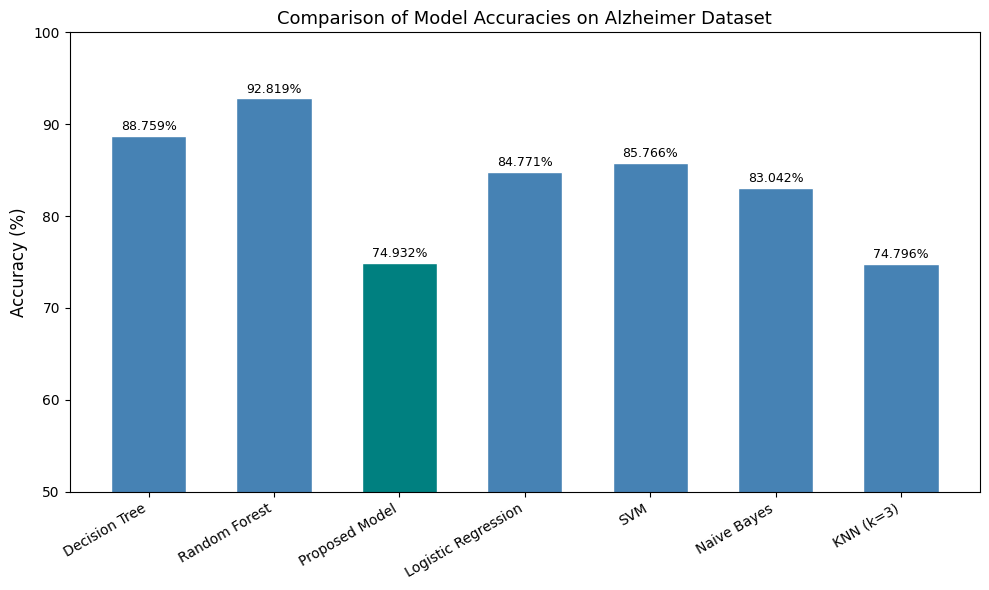

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ── All Model Accuracy Summary ──
models = [
    'Decision Tree',
    'Random Forest',
    'Proposed Model',
    'Logistic Regression',
    'SVM',
    'Naive Bayes',
    'KNN (k=3)'
]

accuracies = [
    dt_scores.mean()*100,
    rf_scores.mean()*100,
    proposed_scores.mean()*100,
    lr_scores.mean()*100,
    svm_scores.mean()*100,
    gnb_scores.mean()*100,
    scores_3.mean()*100
]

# ── Print Table ──
print("=== Final Accuracy Comparison ===")
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for model, acc in zip(models, accuracies):
    print(f"{model:<25} {acc:>9.3f}%")

# ── Bar Chart ──
plt.figure(figsize=(10, 6))

# Proposed Model teal, others steelblue
colors = ['steelblue', 'steelblue', 'teal', 'steelblue', 'steelblue', 'steelblue', 'steelblue']
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', width=0.6)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparison of Model Accuracies on Alzheimer Dataset', fontsize=13)
plt.ylim(50, 100)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.3f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()